In [21]:
# import necessary libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
import xgboost as xgb # extreme gradient boosting 
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, roc_curve
import joblib #to save and load the model
import os 

import warnings
warnings.filterwarnings("ignore") # Filter out all warnings

In [2]:
fweb=gpd.read_file("flood_data/Webflood_inventory.shp")
fweb.head()

,elevation,landuse,rainfall,population,soil,label,geometry
0,20,7,1520.80,23793.40,11,1,POINT (542632.001 729674.241)
1,7,7,1543.22,18602.20,0,1,POINT (542644.073 721168.759)
2,-1,4,1533.90,2886.91,0,1,POINT (552335.359 732321.398)
3,4,7,1545.13,6622.36,11,1,POINT (553842.320 729766.968)
4,6,7,1561.52,2567.51,11,1,POINT (536115.279 709356.734)


In [3]:
#get the summary statistics of the datafrmae
fweb.describe().T

,count,mean,std,min,25%,50%,75%,max
elevation,370.0,14.829730,13.498196,-1.00,5.25000,10.000,20.0000,71.00
landuse,370.0,5.494595,2.473978,1.00,2.00000,7.000,7.0000,11.00
rainfall,370.0,1574.021784,97.483123,1379.56,1510.69250,1552.005,1662.6475,1816.25
population,370.0,6908.354443,11653.563747,-9999.00,338.36125,2267.135,8671.7125,103280.00
soil,370.0,-21.313514,520.157136,-9999.00,0.00000,4.000,11.0000,29.00
label,370.0,0.500000,0.500677,0.00,0.00000,0.500,1.0000,1.00


<Axes: xlabel='label', ylabel='count'>

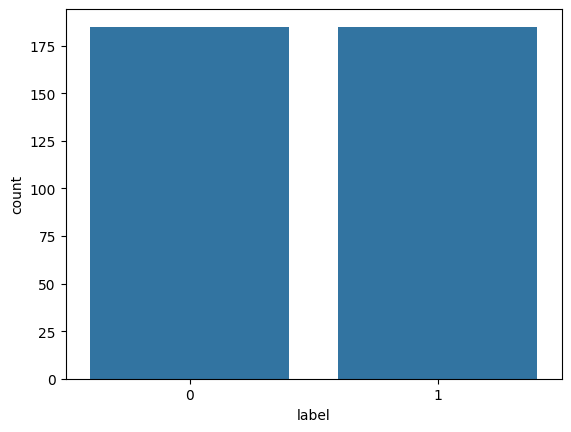

In [ ]:
#Understand the data 
# The dataset includes the same number of flooded and non flooded locations
sns.countplot(x="label", data=fweb) #0 - Nonflooded   1 - Flooded

#### Multicolonierity

In [6]:
# Define function for the VIF and TOL
def calculate_vif(X):
    """Calculates the variance inflation factor (VIF) for all independent variables in a NumPy array X."""
    vif = []
    corr_matrix = np.corrcoef(X.T)
    for i in range(X.shape[1]):
        diag = np.diag(corr_matrix)
        subdiag = corr_matrix[i, i+1:]
        vif.append(1 / (1 - np.sum(subdiag**2) / diag[i]))
    return vif

def calculate_tolerance(X):
    """Calculates the tolerance for all independent variables in a NumPy array X."""
    tolerance = []
    corr_matrix = np.corrcoef(X.T)
    for i in range(X.shape[1]):
        diag = np.diag(corr_matrix)
        subdiag = corr_matrix[i, i+1:]
        tolerance.append(1 - np.sum(subdiag**2) / diag[i])
    return tolerance

VIF and tolerance scores:
     variable       VIF  tolerance
1     landuse  1.278502   0.782165
0   elevation  1.117795   0.894618
2    rainfall  1.091754   0.915957
3  population  1.000807   0.999193
4        soil  1.000000   1.000000


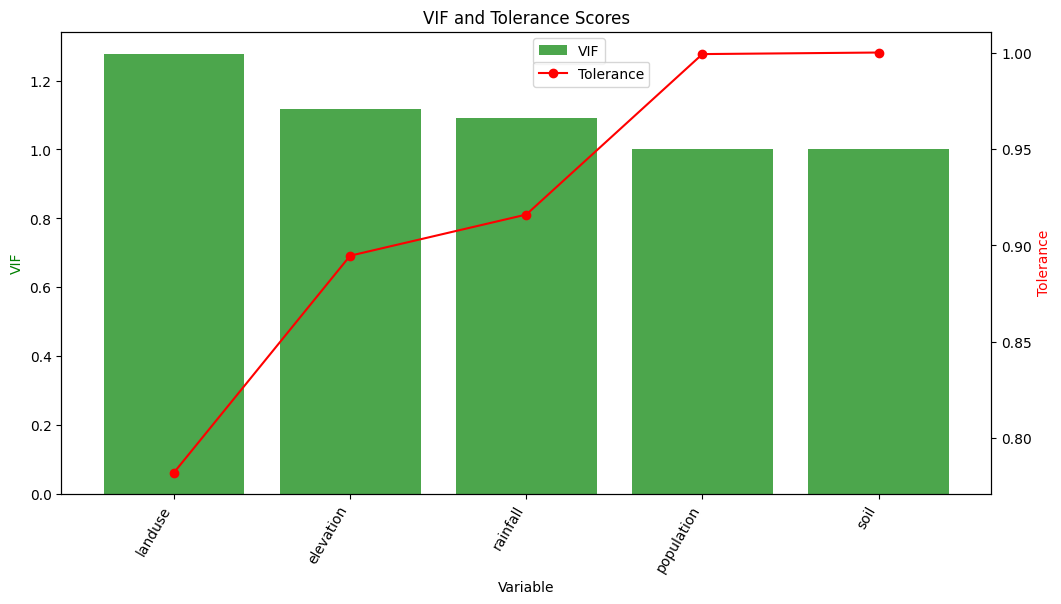

In [ ]:
# Drop the columns not needed in the analysis
columns_to_exclude = [ 'geometry', 'label']
X = fweb.drop(columns_to_exclude, axis=1).values
# Calculate the VIF and tolerance for the independent variables
vif = calculate_vif(X)
tolerance = calculate_tolerance(X)

# Create DataFrames for VIF and tolerance scores
vif_df = pd.DataFrame({'variable': fweb.drop(columns_to_exclude, axis=1).columns, 'VIF': vif})
tolerance_df = pd.DataFrame({'variable': fweb.drop(columns_to_exclude, axis=1).columns, 'tolerance': tolerance})

# Combine the VIF and tolerance DataFrames into a single DataFrame using an inner join
col_df = vif_df.merge(tolerance_df, on='variable', how='inner')
col_df = col_df.sort_values(by='VIF', ascending=False)


# Print the  DataFrame
print("VIF and tolerance scores:")
print(col_df[['variable', 'VIF', 'tolerance']])


#### Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.xticks(rotation=60, ha='right')
ax1.bar(col_df['variable'], col_df['VIF'], color='green', alpha=0.7, label='VIF')
# Creating a second y-axis for tolerance
ax2 = ax1.twinx()
ax2.plot(col_df['variable'], col_df['tolerance'], color='red', marker='o', label='Tolerance')

# Setting labels, legends and title
ax1.set_xlabel('Variable')
ax1.set_ylabel('VIF', color='g')
ax2.set_ylabel('Tolerance', color='r')
plt.title('VIF and Tolerance Scores')
ax1.legend(loc='upper left', bbox_to_anchor=(0.5, 1.0))
ax2.legend(loc='upper left', bbox_to_anchor=(0.5, 0.95))

# Remove gridline
ax2.yaxis.grid(which='major', color='gray', linestyle=' ', linewidth=0.5)

plt.show()

Pearson correlation

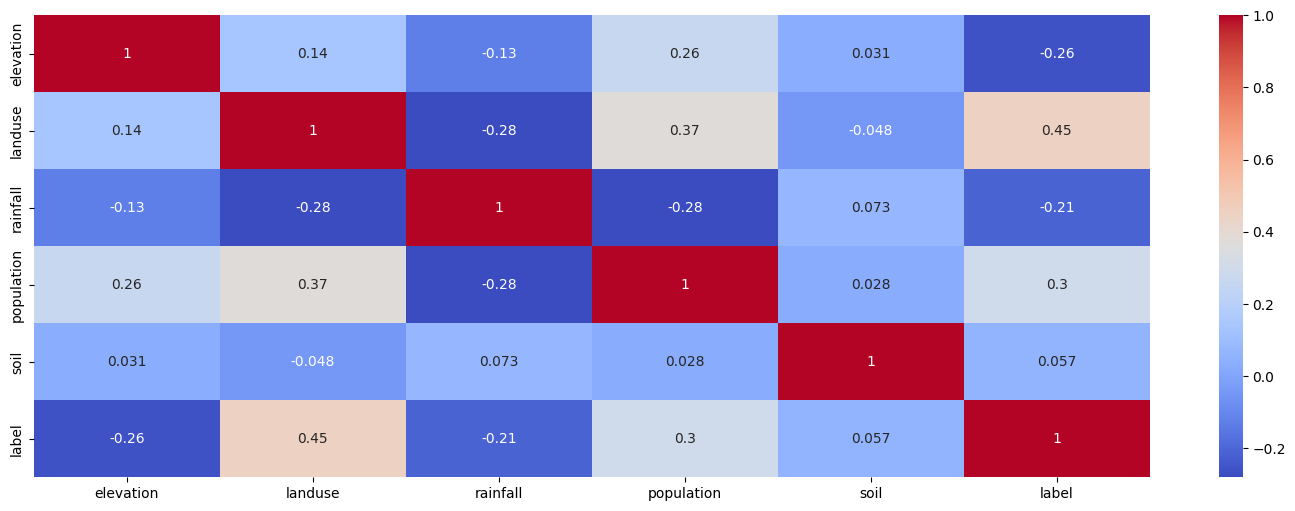

In [13]:
# Calculate the correlation coefficients
plt.figure(figsize=(18, 6))
fweb_geo = fweb.drop(columns=['geometry'], errors='ignore')
correlation_matrix = fweb_geo.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

#### Data Nomilization and spliting 

In [14]:
#Extract the columns to be excluded from normalization
columns_to_exclude = ['label', 'soil', 'landuse', 'geometry']

# Separate the columns to be normalized
columns_to_normalize = [col for col in fweb.columns if col not in columns_to_exclude]

# Initialize the scaler
scaler = MinMaxScaler()

# Normalize only the selected columns
normalized_data = scaler.fit_transform(fweb[columns_to_normalize])
gdf_normalized = fweb.copy()  # Make a copy of the original DataFrame
gdf_normalized[columns_to_normalize] = normalized_data

# Split the dataset into a training set (80%) and a test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    gdf_normalized.drop(columns=['label','geometry' ]),  # Features (independent variables)
    gdf_normalized['label'],  # Target variable (dependent variable)
    test_size=0.3,
    shuffle=True,
    stratify=gdf_normalized['label'],
    random_state=42
)

In [15]:
(len(X_train)), (len(y_train)), (len(X_test)), (len(y_test))

(259, 259, 111, 111)

In [16]:
print(X_train.head())
print(y_train.head())

     elevation  landuse  rainfall  population  soil
152   0.097222        7  0.446404    0.121023     0
14    0.055556       11  0.084385    0.096552     0
26    0.055556        7  0.333623    0.172502    11
99    0.180556        2  0.744739    0.089679     0
157   0.152778        7  0.419932    0.187379     0
152    1
14     1
26     1
99     1
157    1
Name: label, dtype: int64


### Model and Evaluation

Random Forest

In [17]:
# train the model on train set 
RF = RandomForestClassifier() 
RF.fit(X_train, y_train) 
  
# print prediction results 
predictions = RF.predict(X_test) 
print(classification_report(y_test, predictions)) 

              precision    recall  f1-score   support

           0       0.84      0.77      0.80        56
           1       0.78      0.85      0.82        55

    accuracy                           0.81       111
   macro avg       0.81      0.81      0.81       111
weighted avg       0.81      0.81      0.81       111



In [18]:
### Random forest parameter tuning 
param_grid = {'n_estimators':np.arange(10,300,20),
              'max_depth':np.arange(1,20,1) 
            #   'min_samples_leaf': np.arange(1, 10, 1)
            }
rfclassifier = RandomForestClassifier(random_state=11)
RF_model = GridSearchCV(rfclassifier, param_grid, scoring='accuracy', cv=10, refit=True, return_train_score=True, verbose=3, n_jobs=-1)
RF_model.fit(X_train, y_train)

Fitting 10 folds for each of 285 candidates, totalling 2850 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=11),
             n_jobs=-1,
             param_grid={'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'n_estimators': array([ 10,  30,  50,  70,  90, 110, 130, 150, 170, 190, 210, 230, 250,
       270, 290])},
             return_train_score=True, scoring='accuracy', verbose=3)

In [19]:
RF_model.best_params_

{'max_depth': 8, 'n_estimators': 70}

Accuracy for test dataset: 0.8378378378378378
Sensitivity for test dataset: 0.8909090909090909
Specificity for test dataset: 0.7857142857142857
Kappa score for test dataset: 0.6759649691858579



classification report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        56
           1       0.80      0.89      0.84        55

    accuracy                           0.84       111
   macro avg       0.84      0.84      0.84       111
weighted avg       0.84      0.84      0.84       111



Text(0.5, 1.0, 'Confusion Matrix of RF model')

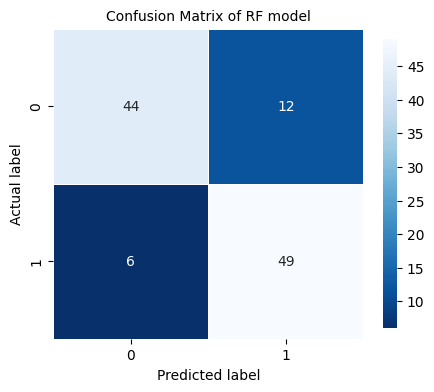

In [22]:
#Evaluate the model on best parameters
ytest_RF_predict = RF_model.predict(X_test)

# ## Evaluate the model
print("Accuracy for test dataset:", accuracy_score(y_test, ytest_RF_predict))
print("Sensitivity for test dataset:", recall_score(y_test,ytest_RF_predict, pos_label=1))
print("Specificity for test dataset:", recall_score(y_test, ytest_RF_predict, pos_label=0))
print("Kappa score for test dataset:", cohen_kappa_score(y_test, ytest_RF_predict))
# Add empty lines for spacing
print("\n" * 2)

print("classification report:")
print(classification_report(y_test, ytest_RF_predict))
CM_RF = confusion_matrix(y_test, ytest_RF_predict)
plt.figure(figsize=(5,5))
sns.heatmap(CM_RF, annot=True, fmt="d", linewidths=.5, square = True, cmap = 'Blues_r', cbar_kws={"shrink": 0.75});
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'Confusion Matrix of RF model'
plt.title(title, size = 10)

AdaBoost

In [23]:
# train the model on train set 
ADB = AdaBoostClassifier() 
ADB.fit(X_train, y_train) 
  
# print prediction results 
y_ADB_pred = ADB.predict(X_test) 
print(classification_report(y_test, y_ADB_pred)) 

              precision    recall  f1-score   support

           0       0.85      0.71      0.78        56
           1       0.75      0.87      0.81        55

    accuracy                           0.79       111
   macro avg       0.80      0.79      0.79       111
weighted avg       0.80      0.79      0.79       111



In [24]:
### Adaboost parameter tuning 
param_grid = {'n_estimators':np.arange(10,220,10), 
              'learning_rate': [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1]}
abclassifier = AdaBoostClassifier(random_state=11)
ADB_model = GridSearchCV(abclassifier, param_grid, scoring='accuracy', cv=10, refit=True, return_train_score=True, verbose=3, n_jobs=-1)
ADB_model.fit(X_train, y_train)

Fitting 10 folds for each of 336 candidates, totalling 3360 fits


GridSearchCV(cv=10, estimator=AdaBoostClassifier(random_state=11), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.002, 0.003, 0.005, 0.007,
                                           0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4,
                                           0.5, 0.6, 0.8, 1],
                         'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200, 210])},
             return_train_score=True, scoring='accuracy', verbose=3)

In [25]:
ADB_model.best_params_

{'learning_rate': 0.4, 'n_estimators': 50}

Accuracy for test dataset: 0.7747747747747747
Sensitivity for test dataset: 0.8727272727272727
Specificity for test dataset: 0.6785714285714286
Kappa score for test dataset: 0.5503159941662615



classification report:
              precision    recall  f1-score   support

           0       0.84      0.68      0.75        56
           1       0.73      0.87      0.79        55

    accuracy                           0.77       111
   macro avg       0.79      0.78      0.77       111
weighted avg       0.79      0.77      0.77       111



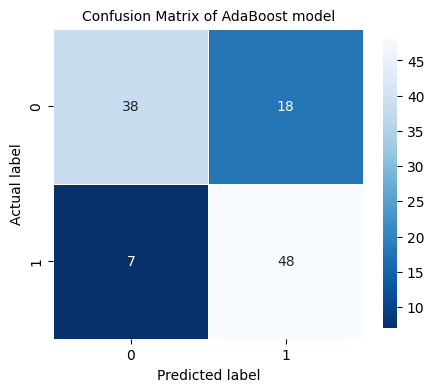

In [26]:
ytest_ADB_predict = ADB_model.predict(X_test)

# Evaluate the model
print("Accuracy for test dataset:", accuracy_score(y_test, ytest_ADB_predict))
print("Sensitivity for test dataset:", recall_score(y_test,ytest_ADB_predict, pos_label=1))
print("Specificity for test dataset:", recall_score(y_test, ytest_ADB_predict, pos_label=0))
print("Kappa score for test dataset:", cohen_kappa_score(y_test, ytest_ADB_predict))
# Add empty lines for spacing
print("\n" * 2)

print("classification report:")
print(classification_report(y_test, ytest_ADB_predict))
CM_ADB = confusion_matrix(y_test, ytest_ADB_predict)
plt.figure(figsize=(5,5))
sns.heatmap(CM_ADB, annot=True, fmt="d", linewidths=.5, square = True, cmap = 'Blues_r', cbar_kws={"shrink": 0.75});
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Confusion Matrix of AdaBoost model'
plt.title(all_sample_title, size = 10);

###### XGBOOST 

In [27]:
# train the model on train set 
XGB = xgb.XGBClassifier()
XGB.fit(X_train, y_train) 
  
# print prediction results 
XGB_pred = XGB.predict(X_test) 
print(classification_report(y_test, XGB_pred)) 

              precision    recall  f1-score   support

           0       0.86      0.75      0.80        56
           1       0.77      0.87      0.82        55

    accuracy                           0.81       111
   macro avg       0.82      0.81      0.81       111
weighted avg       0.82      0.81      0.81       111



In [28]:
# Define the hyperparameter grid for XGBoost
param_grid= {
    'n_estimators': np.arange(10, 200, 10),  # Adjust the number of estimators as needed
    'learning_rate': [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 1],
    'max_depth': [3, 4, 5, 6],  # Adjust the maximum depth as needed
}
xgbclassifier = xgb.XGBClassifier(random_state=11)
XGB_model = GridSearchCV(xgbclassifier, param_grid, scoring='accuracy', cv=10, refit=True, return_train_score=True, verbose=3, n_jobs=-1)
# Fit the model to your training data
XGB_model.fit(X_train, y_train)


Fitting 10 folds for each of 1140 candidates, totalling 11400 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=11, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.002, 0.003, 0.005, 0.007,
                                           0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.5,
                                           0.6, 0.8, 1],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190])},
             return_train_score=True, scoring='accuracy', verbose=3)

In [29]:
XGB_model.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

Accuracy for test dataset: 0.7657657657657657
Sensitivity for test dataset: 0.8181818181818182
Specificity for test dataset: 0.7142857142857143
Kappa score for test dataset: 0.5319493999351281



classification report:
              precision    recall  f1-score   support

           0       0.80      0.71      0.75        56
           1       0.74      0.82      0.78        55

    accuracy                           0.77       111
   macro avg       0.77      0.77      0.77       111
weighted avg       0.77      0.77      0.77       111



Text(0.5, 1.0, 'Confusion Matrix of XGB model')

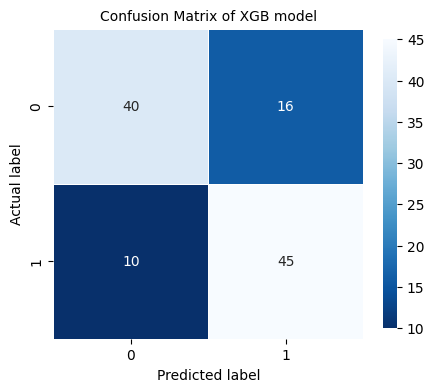

In [30]:
Y_test_XGB_predict = XGB_model.predict(X_test)

# Evaluate the model
print("Accuracy for test dataset:", accuracy_score(y_test, Y_test_XGB_predict))
print("Sensitivity for test dataset:", recall_score(y_test,Y_test_XGB_predict, pos_label=1))
print("Specificity for test dataset:", recall_score(y_test, Y_test_XGB_predict, pos_label=0))
print("Kappa score for test dataset:", cohen_kappa_score(y_test, Y_test_XGB_predict))
# Add empty lines for spacing
print("\n" * 2)

print("classification report:")
print(classification_report(y_test, Y_test_XGB_predict))
CM_XGB = confusion_matrix(y_test, Y_test_XGB_predict)
plt.figure(figsize=(5,5))
sns.heatmap(CM_XGB, annot=True, fmt="d", linewidths=.5, square = True, cmap = 'Blues_r', cbar_kws={"shrink": 0.75});
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'Confusion Matrix of XGB model'
plt.title(title, size = 10)

### Plot the roc curve

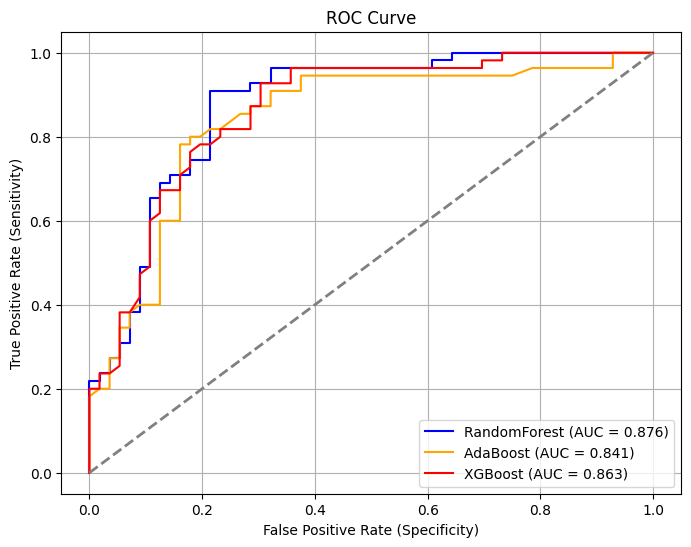

In [31]:
# plot the roc for all model 
# Predict probabilities models on the test data
y_prob_RF = RF_model.predict_proba(X_test)[:, 1]
y_prob_ADB = ADB_model.predict_proba(X_test)[:, 1]
y_prob_XGB = XGB_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve for each model
fpr_RF, tpr_RF, _ = roc_curve(y_test, y_prob_RF)
fpr_ADB, tpr_ADB, _ = roc_curve(y_test, y_prob_ADB)
fpr_XGB, tpr_XGB, _ = roc_curve(y_test, y_prob_XGB)

# Calculate ROC AUC for each model
roc_auc_RF = roc_auc_score(y_test, y_prob_RF)
roc_auc_ADB = roc_auc_score(y_test, y_prob_ADB)
roc_auc_XGB = roc_auc_score(y_test, y_prob_XGB)

# Plot ROC curves for both models
plt.figure(figsize=(8, 6))
plt.plot(fpr_RF, tpr_RF, label=f'RandomForest (AUC = {roc_auc_RF:.3f})', color='blue')
plt.plot(fpr_ADB, tpr_ADB, label=f'AdaBoost (AUC = {roc_auc_ADB:.3f})', color='orange')
plt.plot(fpr_XGB, tpr_XGB, label=f'XGBoost (AUC = {roc_auc_XGB:.3f})', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2)
plt.xlabel('False Positive Rate (Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

#### Save model

In [32]:
models_directory = 'model_pkl/'
os.makedirs(models_directory, exist_ok=True)

In [33]:
# # # Save the best model to a file using Joblib
# Save Random Forest
joblib.dump(RF_model, os.path.join(models_directory, 'RandomForest_model.pkl'))

# Save AdaBoost
joblib.dump(ADB_model, os.path.join(models_directory, 'AdaBoost_model.pkl'))

# Save XGBoost
joblib.dump(XGB_model, os.path.join(models_directory, 'XGBoost_model.pkl'))

['model_pkl/XGBoost_model.pkl']

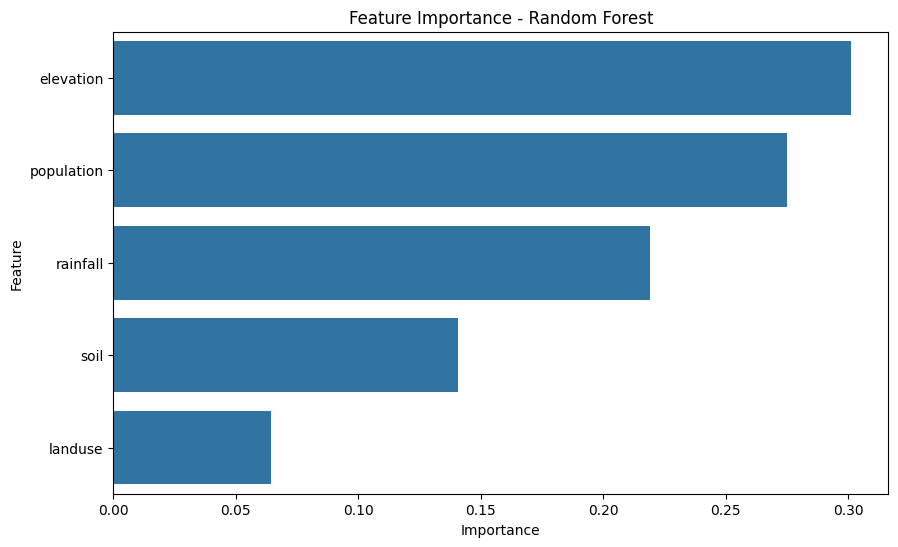

In [ ]:
# Feature importance using the best model
importance = RF_model.best_estimator_.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x='Importance', y='Feature')
plt.title("Feature Importance - Random Forest")
plt.show()
